In [37]:
#@title Welcome to Global Plus 360 model
!pip install -q feedparser # for reading RSS feed

import pandas as pd
import urllib.parse, feedparser
from datetime import datetime, timedelta

# Get the default start/end date as current week
DATE_FORMAT = '%Y-%m-%d'
today_date = (datetime.now() + timedelta(days=1)).strftime(DATE_FORMAT)
seven_days_ago = (datetime.now() - timedelta(days=7)).strftime(DATE_FORMAT)

# Enable Google interactive table
from google.colab import data_table
data_table.enable_dataframe_formatter()

# Display LLM output text
from IPython.display import Markdown, display

def displayLLMOutput(llmOutput):
  display(Markdown(f"<font size='4'>{llmOutput}</font>"))

from google.colab import ai
displayLLMOutput("The free LLM models from Google Colab:")
displayLLMOutput(ai.list_models())

<font size='4'>The free LLM models from Google Colab:</font>

<font size='4'>['google/gemini-2.5-flash', 'google/gemini-2.5-flash-lite', 'google/gemini-2.5-pro', 'google/gemini-3.1-pro-preview', 'google/gemini-3.5-flash']</font>

## Use **RSS feed** to get the news for the the Markets. Then use LLM to summarize it and provide resaons for Market Movement and strategies

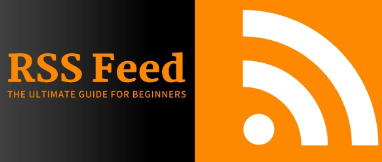

In [38]:
!pip install feedparser -q

In [39]:
# @title Part 1.1 Market Index Performance Tracker & Selective News Scraping
# @markdown Run this cell to calculate global index performance and fetch targeted news.

from datetime import datetime, timedelta
import time
import urllib.parse
import feedparser
import pandas as pd
import yfinance as yf

# 1. Map yfinance index tickers to human-readable names and news search queries
index_info = {
    "^GSPC": {"name": "S&P 500 (US)", "query": "S&P 500 index"},
    "^DJI": {
        "name": "Dow Jones Industrial Average (US)",
        "query": "Dow Jones index",
    },
    "^IXIC": {"name": "Nasdaq Composite (US)", "query": "Nasdaq Composite"},
    "^RUT": {"name": "Russell 2000 (US)", "query": "Russell 2000 index"},
    "^STOXX": {"name": "STOXX Europe 600", "query": "STOXX Europe 600"},
    "^FTSE": {"name": "FTSE 100 (UK)", "query": "FTSE 100 index"},
    "^GDAXI": {"name": "DAX 40 (Germany)", "query": "DAX 40 index"},
    "^FCHI": {"name": "CAC 40 (France)", "query": "CAC 40 index"},
    "^STOXX50E": {"name": "EURO STOXX 50", "query": "EURO STOXX 50"},
    "^N225": {"name": "Nikkei 225 (Japan)", "query": "Nikkei 225 index"},
    "^HSI": {
        "name": "Hang Seng Index (Hong Kong)",
        "query": "Hang Seng Index",
    },
    "000001.SS": {
        "name": "Shanghai Composite (China)",
        "query": "Shanghai Composite index",
    },
    "399001.SZ": {
        "name": "SZSE Component (China)",
        "query": "Shenzhen Component index",
    },
    "^TWII": {"name": "TAIEX (Taiwan)", "query": "TAIEX index Taiwan"},
    "^KS11": {"name": "KOSPI (South Korea)", "query": "KOSPI index Korea"},
    "^BSESN": {"name": "BSE Sensex (India)", "query": "BSE Sensex index"},
    "^STI": {
        "name": "Straits Times Index (Singapore)",
        "query": "Straits Times Index Singapore",
    },
    "^AXJO": {"name": "S&P/ASX 200 (Australia)", "query": "ASX 200 index"},
    "^GSPTSE": {
        "name": "S&P/TSX Composite (Canada)",
        "query": "TSX Composite index",
    },
    "^BVSP": {"name": "Bovespa (Brazil)", "query": "Bovespa index"},
    "^SET": {"name": "SET Index (Thailand)", "query": "Thailand SET index"},
    "^JKSE": {
        "name": "Jakarta Composite Index (Indonesia)",
        "query": "Jakarta Composite Index Indonesia",
    },
    "^KLSE": {
        "name": "FTSE Bursa Malaysia KLCI (Malaysia)",
        "query": "Bursa Malaysia KLCI index",
    },

}

# 2. Interactive Date Parameters for Google Colab
startDate = "2026-06-30"  # @param {type:"date"}
endDate = "2026-07-31"  # @param {type:"date"}

# Adjust query_end_date by +1 day because yfinance `end` parameter is EXCLUSIVE
end_dt = datetime.strptime(endDate, "%Y-%m-%d") + timedelta(days=1)
query_end_date = end_dt.strftime("%Y-%m-%d")

# 3. Fetch Historical Data & Calculate Performance
tickers = list(index_info.keys())
data = yf.download(
    tickers,
    start=startDate,
    end=query_end_date,
    progress=False,
    ignore_tz=True,
)

# Extract close prices cleanly
if isinstance(data.columns, pd.MultiIndex):
  close_prices = data["Close"].copy()
else:
  close_prices = data.copy()

# Forward-fill & back-fill missing prices due to regional holidays
close_prices = close_prices.dropna(axis=1, how="all").ffill().bfill()

# Calculate performance percentage
start_vals = close_prices.iloc[0]
end_vals = close_prices.iloc[-1]
performance = ((end_vals - start_vals) / start_vals) * 100

# Verify actual trading dates retrieved
actual_start_date = close_prices.index[0].strftime("%Y-%m-%d")
actual_end_date = close_prices.index[-1].strftime("%Y-%m-%d")

# Build DataFrame and sort performance
df_perf = pd.DataFrame(
    {"Ticker": performance.index, "Return (%)": performance.values}
)
df_perf["Index Name"] = df_perf["Ticker"].map(
    lambda x: index_info.get(x, {}).get("name", x)
)
df_perf_sorted = df_perf.sort_values(
    by="Return (%)", ascending=False
).reset_index(drop=True)

# Display Overall Top & Bottom Summaries
df_top5_display = df_perf_sorted.head(5)[["Index Name", "Return (%)"]].copy()
df_top5_display["Return (%)"] = df_top5_display["Return (%)"].apply(
    lambda x: f"{x:+.2f}%"
)

df_bottom5_display = (
    df_perf_sorted.tail(5)[["Index Name", "Return (%)"]].iloc[::-1].copy()
)
df_bottom5_display["Return (%)"] = df_bottom5_display["Return (%)"].apply(
    lambda x: f"{x:+.2f}%"
)

print("==================================================")
print(f" GLOBAL PERFORMANCE SUMMARY ({actual_start_date} to {actual_end_date})")
print("==================================================\n")

print("🟢 TOP 5 BEST PERFORMERS:")
display(df_top5_display)

print("\n🔴 BOTTOM 5 WORST PERFORMERS:")
display(df_bottom5_display)

# 4. Interactive Selection Options (Both Active)
# @markdown ---
# @markdown ### ⚙️ Active Controls (Both selections will be included simultaneously):
group_selection = "All Indices"  # @param ["Top 5 Performers", "Bottom 5 Performers", "All Indices"]
specific_index = "Hang Seng Index (Hong Kong)"  # @param ["S&P 500 (US)", "Dow Jones Industrial Average (US)", "Nasdaq Composite (US)", "Russell 2000 (US)", "STOXX Europe 600", "FTSE 100 (UK)", "DAX 40 (Germany)", "CAC 40 (France)", "EURO STOXX 50", "Nikkei 225 (Japan)", "Hang Seng Index (Hong Kong)", "Shanghai Composite (China)", "SZSE Component (China)", "TAIEX (Taiwan)", "KOSPI (South Korea)", "BSE Sensex (India)", "Straits Times Index (Singapore)", "S&P/ASX 200 (Australia)", "S&P/TSX Composite (Canada)", "Bovespa (Brazil)", "SET Index (Thailand)", "Jakarta Composite Index (Indonesia)", "FTSE Bursa Malaysia KLCI (Malaysia)", "PSEi Composite (Philippines)"]

# Filter Group Selection Target
if group_selection == "Top 5 Performers":
  df_group = df_perf_sorted.head(5)
elif group_selection == "Bottom 5 Performers":
  df_group = df_perf_sorted.tail(5)
else:
  df_group = df_perf_sorted

# Filter Single Index Target
df_single = df_perf_sorted[df_perf_sorted["Index Name"] == specific_index]

# Combine both selections, dropping duplicates if single index overlaps with chosen group
df_targets = pd.concat([df_group, df_single]).drop_duplicates(subset=["Ticker"]).reset_index(drop=True)

# Print Performance for the specifically selected index
single_return = df_single["Return (%)"].values[0] if not df_single.empty else 0.0
print("\n" + "=" * 50)
print(f" 🎯 SPECIFICALLY SELECTED INDEX PERFORMANCE")
print(f" • {specific_index}: {single_return:+.2f}%")
print("=" * 50)

# 5. Scrape RSS News for Combined Selection
all_news_data = []

for idx, row in df_targets.iterrows():
  ticker = row["Ticker"]
  name = row["Index Name"]
  raw_query = index_info[ticker]["query"]

  full_query = f"{raw_query} after:{startDate} before:{query_end_date}"
  encoded_query = urllib.parse.quote(full_query)
  feed_url = f"https://news.google.com/rss/search?q={encoded_query}&hl=en-US&gl=US&ceid=US:en"

  feed = feedparser.parse(feed_url)

  for entry in feed.entries:
    all_news_data.append({
        "Index Name": name,
        "Publication Date": getattr(entry, "published", "N/A"),
        "Title": entry.title,
        "Link": entry.link,
    })

  time.sleep(0.4)

# Display News Table
df_news = pd.DataFrame(all_news_data)

print("\n" + "=" * 50)
print(f" 📰 RSS NEWS ({group_selection} + {specific_index}): {len(df_news)} ARTICLES FOUND")
print("=" * 50 + "\n")

if not df_news.empty:
  display(df_news)
else:
  print("No news articles found for the chosen criteria.")

ERROR:yfinance:$^SET: possibly delisted; no price data found  (1d 2026-06-30 -> 2026-08-01)
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['^SET']: possibly delisted; no price data found  (1d 2026-06-30 -> 2026-08-01)


 GLOBAL PERFORMANCE SUMMARY (2026-06-30 to 2026-07-31)

🟢 TOP 5 BEST PERFORMERS:


,Index Name,Return (%)
0,Hang Seng Index (Hong Kong),+13.13%
1,Jakarta Composite Index (Indonesia),+10.51%
2,Straits Times Index (Singapore),+8.85%
3,FTSE Bursa Malaysia KLCI (Malaysia),+3.66%
4,FTSE 100 (UK),+3.53%



🔴 BOTTOM 5 WORST PERFORMERS:


,Index Name,Return (%)
21,KOSPI (South Korea),-22.19%
20,SZSE Component (China),-16.21%
19,Nikkei 225 (Japan),-8.14%
18,TAIEX (Taiwan),-6.52%
17,Shanghai Composite (China),-6.40%



 🎯 SPECIFICALLY SELECTED INDEX PERFORMANCE
 • Hang Seng Index (Hong Kong): +13.13%

 📰 RSS NEWS (All Indices + Hang Seng Index (Hong Kong)): 1795 ARTICLES FOUND



,Index Name,Publication Date,Title,Link
0,Hang Seng Index (Hong Kong),"Sun, 19 Jul 2026 07:00:00 GMT",Hong Kong Market Midday Report | Hang Seng Ind...,https://news.google.com/rss/articles/CBMinAFBV...
1,Hang Seng Index (Hong Kong),"Thu, 09 Jul 2026 07:00:00 GMT",Hong Kong stocks retreat as regional tech vola...,https://news.google.com/rss/articles/CBMixAFBV...
2,Hang Seng Index (Hong Kong),"Thu, 16 Jul 2026 07:00:00 GMT","Hang Seng Index Reclaims 25,000 as Tech Stocks...",https://news.google.com/rss/articles/CBMirwFBV...
3,Hang Seng Index (Hong Kong),"Thu, 16 Jul 2026 07:00:00 GMT",Hang Seng Index down 1.98% by midday - chinada...,https://news.google.com/rss/articles/CBMiWkFVX...
4,Hang Seng Index (Hong Kong),"Fri, 31 Jul 2026 07:00:00 GMT",Prince – 'Hang Seng Index Breaks Through the B...,https://news.google.com/rss/articles/CBMirgFBV...
...,...,...,...,...
1790,KOSPI (South Korea),"Tue, 28 Jul 2026 07:00:00 GMT",Asian shares slip and South Korea’s Kospi inde...,https://news.google.com/rss/articles/CBMiVkFVX...
1791,KOSPI (South Korea),"Tue, 28 Jul 2026 07:00:00 GMT","KOSPI index plunges 10.84% to 6,023.66 on heav...",https://news.google.com/rss/articles/CBMibEFVX...
1792,KOSPI (South Korea),"Tue, 28 Jul 2026 09:39:33 GMT",[Closing Market] KOSPI Plunges 10.84% on Chip ...,https://news.google.com/rss/articles/CBMidEFVX...
1793,KOSPI (South Korea),"Fri, 31 Jul 2026 07:00:00 GMT",Humbling times for markets - ft.com,https://news.google.com/rss/articles/CBMihAFBV...


In [41]:
# ==============================================================================
# Prepare Headlines & Summarize using AI
# ==============================================================================
from google.colab import ai
from IPython.display import display, Markdown

# Check if we have gathered any news before attempting to summarize
if not df_news.empty:

  # Format headlines grouped by Index Name into a single string
  formatted_headlines = []
  for name, group in df_news.groupby("Index Name"):
    formatted_headlines.append(f"### Index: {name}")
    for idx, row in group.iterrows():
      formatted_headlines.append(
          f"- {row['Title']} (Published: {row['Publication Date']})"
      )
    formatted_headlines.append("")  # Blank line separator

  # Combine into the `all_headlines` variable required by your summary cell
  all_headlines = "\n".join(formatted_headlines)

  # @title Part 1.2. Summarize the news
  question = "Summarise the news for each index briefly based on the provided headlines."  # @param {type:"string"}
  questionWithContext = (
      question + " Use the following context: \n\n" + all_headlines
  )

  # Generate and display output using Google Colab's built-in AI module
  result = ai.generate_text(questionWithContext)

  # Render the result cleanly as Markdown
  display(Markdown(result))

else:
  print("No headlines found to summarise.")

RateLimitError: Error code: 429 - {'code': '', 'message': 'The model is currently experiencing heavy load. Try again later.', 'param': '', 'type': 'rate_limit_error'}

In [4]:
!pip install --upgrade yfinance ipywidgets pandas --no-cache-dir

In [5]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [6]:
# @title Shared helpers for Part 3+ (fixed)
import json
import textwrap
from IPython.display import display, Markdown, HTML, clear_output
import ipywidgets as widgets
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date, timedelta

# ------------------------------------------------------------------
# Handle both possible formats of index_info
# ------------------------------------------------------------------
if 'index_info' not in globals():
    # Fallback definition (simple format)
    index_info = {
        "^GSPC": "S&P 500 (US)",
        "^DJI": "Dow Jones Industrial Average (US)",
        "^IXIC": "Nasdaq Composite (US)",
        "^RUT": "Russell 2000 (US)",
        "^STOXX": "STOXX Europe 600",
        "^FTSE": "FTSE 100 (UK)",
        "^GDAXI": "DAX 40 (Germany)",
        "^FCHI": "CAC 40 (France)",
        "^STOXX50E": "EURO STOXX 50",
        "^N225": "Nikkei 225 (Japan)",
        "^HSI": "Hang Seng Index (Hong Kong)",
        "000001.SS": "Shanghai Composite (China)",
        "399001.SZ": "SZSE Component (China)",
        "^TWII": "TAIEX (Taiwan)",
        "^KS11": "KOSPI (South Korea)",
        "^BSESN": "BSE Sensex (India)",
        "^STI": "Straits Times Index (Singapore)",
        "^AXJO": "S&P/ASX 200 (Australia)",
        "^GSPTSE": "S&P/TSX Composite (Canada)",
        "^BVSP": "Bovespa (Brazil)"
    }

# Convert to simple {ticker: name} format no matter what
first_value = next(iter(index_info.values()))
if isinstance(first_value, dict):
    # Part 1 format → extract the "name"
    simple_index_info = {ticker: info["name"] for ticker, info in index_info.items()}
else:
    # Already simple format
    simple_index_info = index_info

# Now create the mappings that the rest of the notebook needs
ticker_by_name = {v: k for k, v in simple_index_info.items()}
all_names = list(simple_index_info.values())

print("✅ Shared helpers ready")
print(f"Number of indices available: {len(all_names)}")

✅ Shared helpers ready
Number of indices available: 23


In [42]:
# @title Part 2 – Current Portfolio Editor + Snapshot + Risk Metrics
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import date, datetime, timedelta
import ipywidgets as widgets
from IPython.display import display, Markdown, HTML, clear_output

# ------------------------------------------------------------------
# 0. Index mapping – handles both Part 1 (nested) and simple formats
# ------------------------------------------------------------------
if 'index_info' not in globals():
    index_info = {
        "^GSPC": "S&P 500 (US)",
        "^DJI": "Dow Jones Industrial Average (US)",
        "^IXIC": "Nasdaq Composite (US)",
        "^RUT": "Russell 2000 (US)",
        "^STOXX": "STOXX Europe 600",
        "^FTSE": "FTSE 100 (UK)",
        "^GDAXI": "DAX 40 (Germany)",
        "^FCHI": "CAC 40 (France)",
        "^STOXX50E": "EURO STOXX 50",
        "^N225": "Nikkei 225 (Japan)",
        "^HSI": "Hang Seng Index (Hong Kong)",
        "000001.SS": "Shanghai Composite (China)",
        "399001.SZ": "SZSE Component (China)",
        "^TWII": "TAIEX (Taiwan)",
        "^KS11": "KOSPI (South Korea)",
        "^BSESN": "BSE Sensex (India)",
        "^STI": "Straits Times Index (Singapore)",
        "^AXJO": "S&P/ASX 200 (Australia)",
        "^GSPTSE": "S&P/TSX Composite (Canada)",
        "^BVSP": "Bovespa (Brazil)"
    }

# Convert to simple {ticker: name} no matter which format is present
first_value = next(iter(index_info.values()))
if isinstance(first_value, dict):
    # Coming from Part 1 (nested format)
    simple_index_info = {ticker: info["name"] for ticker, info in index_info.items()}
else:
    # Already simple format
    simple_index_info = index_info

ticker_by_name = {name: ticker for ticker, name in simple_index_info.items()}
all_names = list(simple_index_info.values())

print(f"✅ {len(all_names)} indices loaded successfully")

# ------------------------------------------------------------------
# 1. UI Controls
# ------------------------------------------------------------------
start_date_picker = widgets.DatePicker(
    description='Start Date:',
    value=date.today() - timedelta(days=365)
)
end_date_picker = widgets.DatePicker(
    description='End Date:',
    value=date.today()
)
rf_rate_input = widgets.BoundedFloatText(
    value=4.0, min=0.0, max=20.0, step=0.1,
    description='Risk-Free Rate (%):',
    style={'description_width': 'initial'}
)

current_rows = []
current_container = widgets.VBox()
current_status = widgets.HTML()
output_area = widgets.Output()

def make_status_banner(total):
    if abs(total - 100) < 0.5:
        color, txt = "#28a745", "Ready (100% Fully Allocated)"
    elif total < 100:
        color, txt = "#fd7e14", f"Underallocated by {100-total:.1f}%"
    else:
        color, txt = "#dc3545", f"Overallocated by {total-100:.1f}%"
    return f"""
    <div style="font-family:sans-serif; padding:8px 12px; border-radius:5px;
                background:#f8f9fa; border:1px solid #dee2e6; margin-bottom:10px;">
        <b>Total Allocation:
            <span style="color:{color}; font-size:18px;">{total:.1f}% / 100%</span>
        </b>
        <span style="color:{color}; font-size:13px; margin-left:10px;">({txt})</span>
    </div>
    """

def update_status():
    total = sum(r['text'].value for r in current_rows)
    current_status.value = make_status_banner(total)

def enforce_max_total(change):
    widget = change['owner']
    target_row = next((r for r in current_rows if r['text'] is widget or r['slider'] is widget), None)
    if not target_row:
        return
    other_sum = sum(r['text'].value for r in current_rows if r is not target_row)
    max_allowed = max(0, 100 - other_sum)
    new_val = change['new'] if change['new'] is not None else 0
    if new_val > max_allowed:
        target_row['text'].value = target_row['slider'].value = max_allowed
    else:
        if target_row['slider'].value != new_val:
            target_row['slider'].value = new_val
        if target_row['text'].value != new_val:
            target_row['text'].value = new_val
    update_status()

def create_row(selected_name=None, weight_val=0):
    if selected_name is None:
        selected_name = all_names[0]

    dropdown = widgets.Dropdown(
        options=all_names, value=selected_name,
        layout=widgets.Layout(width='260px')
    )
    weight_text = widgets.BoundedIntText(
        value=weight_val, min=0, max=100, step=1,
        description='Weight (%):',
        style={'description_width': '80px'},
        layout=widgets.Layout(width='150px')
    )
    weight_slider = widgets.IntSlider(
        value=weight_val, min=0, max=100, step=1,
        readout=False, layout=widgets.Layout(width='180px')
    )
    remove_btn = widgets.Button(
        description="❌ Remove", button_style='danger',
        layout=widgets.Layout(width='100px')
    )

    weight_text.observe(enforce_max_total, names='value')
    weight_slider.observe(enforce_max_total, names='value')

    row_box = widgets.HBox(
        [dropdown, weight_text, weight_slider, remove_btn],
        layout=widgets.Layout(align_items='center', margin='2px 0px')
    )
    row_data = {
        'box': row_box, 'dropdown': dropdown,
        'text': weight_text, 'slider': weight_slider
    }

    def on_remove(b):
        if len(current_rows) > 1:
            current_rows.remove(row_data)
            current_container.children = [r['box'] for r in current_rows]
            update_status()
    remove_btn.on_click(on_remove)
    return row_data

# Default portfolio
default_portfolio = [
    ("S&P 500 (US)", 40),
    ("Nasdaq Composite (US)", 20),
    ("STOXX Europe 600", 20),
    ("Nikkei 225 (Japan)", 20)
]
for name, w in default_portfolio:
    current_rows.append(create_row(name, w))

current_container.children = [r['box'] for r in current_rows]
update_status()

# Buttons
add_btn = widgets.Button(description="➕ Add Index", button_style='success', icon='plus')
reset_btn = widgets.Button(description="🔄 Reset Weights (0%)", button_style='warning', icon='refresh')
snapshot_btn = widgets.Button(description="📸 Snapshot Current Portfolio", button_style='info', icon='camera')
calc_btn = widgets.Button(description="🚀 Calculate Risk & Return Metrics", button_style='primary', icon='calculator')

def add_new_row(b):
    used = [r['dropdown'].value for r in current_rows]
    next_name = next((n for n in all_names if n not in used), all_names[0])
    current_rows.append(create_row(next_name, 0))
    current_container.children = [r['box'] for r in current_rows]
    update_status()

def reset_weights(b):
    for r in current_rows:
        r['text'].value = 0
        r['slider'].value = 0
    update_status()

def get_current_weights():
    d = {}
    for r in current_rows:
        w = r['text'].value
        if w > 0:
            d[r['dropdown'].value] = float(w)
    total = sum(d.values())
    if total == 0:
        raise ValueError("Portfolio has zero total weight")
    return {k: round(v * 100 / total, 2) for k, v in d.items()}

def on_snapshot(b):
    with output_area:
        clear_output(wait=True)
        try:
            weights = get_current_weights()
        except Exception as e:
            display(Markdown(f"❌ {e}"))
            return

        df = pd.DataFrame([
            {"Index Name": k, "Weight (%)": v}
            for k, v in weights.items()
        ]).sort_values("Weight (%)", ascending=False)

        total = df["Weight (%)"].sum()
        display(HTML(make_status_banner(total)))
        display(Markdown("### 📋 Current Client Portfolio Snapshot"))
        display(HTML(df.to_html(index=False, classes='table table-striped')))
        global current_portfolio_snapshot
        current_portfolio_snapshot = weights
        display(Markdown("✅ Snapshot saved."))

def calculate_metrics(b):
    with output_area:
        clear_output(wait=True)

        try:
            weights = get_current_weights()
        except Exception as e:
            display(Markdown(f"❌ {e}"))
            return

        start_val = start_date_picker.value
        end_val = min(end_date_picker.value, date.today())
        if start_val >= end_val:
            display(Markdown("❌ Start Date must be earlier than End Date."))
            return

        start_d = start_val.strftime('%Y-%m-%d')
        end_d = (end_val + timedelta(days=1)).strftime('%Y-%m-%d')
        rf_annual = rf_rate_input.value / 100.0

        active_names = list(weights.keys())
        active_tickers = [ticker_by_name[n] for n in active_names]
        raw_weights = np.array([weights[n] for n in active_names])

        display(Markdown("⏳ Downloading market data from Yahoo Finance..."))

        try:
            df_download = yf.download(
                tickers=active_tickers,
                start=start_d,
                end=end_d,
                progress=False,
                auto_adjust=True
            )
        except Exception as e:
            display(Markdown(f"❌ Network Error: `{e}`"))
            return

        if df_download.empty:
            display(Markdown("❌ Yahoo Finance returned empty data."))
            return

        if isinstance(df_download.columns, pd.MultiIndex):
            close_prices = df_download['Close'].copy()
        else:
            close_prices = df_download.copy()

        close_prices = close_prices.ffill().bfill().dropna(axis=1, how='all')
        valid_tickers = [t for t in active_tickers if t in close_prices.columns]

        if not valid_tickers:
            display(Markdown("❌ No valid price data for the selected indices."))
            return

        valid_names = [active_names[i] for i, t in enumerate(active_tickers) if t in valid_tickers]
        valid_raw = [raw_weights[i] for i, t in enumerate(active_tickers) if t in valid_tickers]
        valid_w = np.array(valid_raw) / np.sum(valid_raw)

        daily_returns = close_prices[valid_tickers].pct_change().dropna()
        if daily_returns.empty:
            display(Markdown("❌ Not enough overlapping trading days."))
            return

        port_ret = daily_returns.dot(valid_w)
        cum = (1 + port_ret).cumprod()

        total_return = (cum.iloc[-1] - 1) * 100
        trading_days = len(port_ret)
        daily_std = port_ret.std()
        ann_vol = daily_std * np.sqrt(252) * 100
        ann_ret = (1 + port_ret.mean())**252 - 1
        sharpe = (ann_ret - rf_annual) / (daily_std * np.sqrt(252)) if daily_std > 0 else np.nan

        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        max_dd = drawdown.min() * 100

        # Holdings table
        df_weights = pd.DataFrame({
            "Index Name": valid_names,
            "Ticker": valid_tickers,
            "Weight (%)": np.round(valid_w * 100, 2)
        })

        display(Markdown("### 📊 Portfolio Holdings"))
        display(HTML(df_weights.to_html(index=False, classes='table table-striped')))

        # Metric cards
        metrics_html = f"""
        <div style="display:flex; gap:15px; flex-wrap:wrap; font-family:sans-serif; margin-top:15px;">
            <div style="background:#f0f8ff; border-left:5px solid #007bff; padding:12px; border-radius:5px; flex:1; min-width:200px;">
                <h4 style="margin:0; color:#555;">Total Return</h4>
                <p style="font-size:22px; font-weight:bold; margin:5px 0 0 0; color:{'#28a745' if total_return >= 0 else '#dc3545'};">
                    {total_return:+.2f}%
                </p>
                <small style="color:#777;">{trading_days} trading days</small>
            </div>
            <div style="background:#fff3cd; border-left:5px solid #ffc107; padding:12px; border-radius:5px; flex:1; min-width:200px;">
                <h4 style="margin:0; color:#555;">Ann. Volatility</h4>
                <p style="font-size:22px; font-weight:bold; margin:5px 0 0 0;">{ann_vol:.2f}%</p>
                <small style="color:#777;">Annualized Std Dev</small>
            </div>
            <div style="background:#f8d7da; border-left:5px solid #dc3545; padding:12px; border-radius:5px; flex:1; min-width:200px;">
                <h4 style="margin:0; color:#555;">Max Drawdown</h4>
                <p style="font-size:22px; font-weight:bold; margin:5px 0 0 0; color:#dc3545;">{max_dd:.2f}%</p>
                <small style="color:#777;">Peak-to-Trough</small>
            </div>
            <div style="background:#d4edda; border-left:5px solid #28a745; padding:12px; border-radius:5px; flex:1; min-width:200px;">
                <h4 style="margin:0; color:#555;">Sharpe Ratio</h4>
                <p style="font-size:22px; font-weight:bold; margin:5px 0 0 0; color:#155724;">{sharpe:.2f}</p>
                <small style="color:#777;">Rf = {rf_rate_input.value:.1f}%</small>
            </div>
        </div>
        """
        display(Markdown("### 📈 Risk & Return Performance Metrics"))
        display(HTML(metrics_html))

add_btn.on_click(add_new_row)
reset_btn.on_click(reset_weights)
snapshot_btn.on_click(on_snapshot)
calc_btn.on_click(calculate_metrics)

# ------------------------------------------------------------------
# Final Layout (same style as original Part 2)
# ------------------------------------------------------------------
display(Markdown("## 💼 Current Client Portfolio Editor + Risk Metrics"))
display(widgets.HBox([start_date_picker, end_date_picker, rf_rate_input]))
display(widgets.HTML("<hr>"))
display(current_status)
display(current_container)
display(widgets.HBox([add_btn, reset_btn, snapshot_btn, calc_btn]))
display(output_area)

✅ 23 indices loaded successfully


## 💼 Current Client Portfolio Editor + Risk Metrics

HTML(value='<hr>')

HTML(value='\n    <div style="font-family:sans-serif; padding:8px 12px; border-radius:5px;\n                ba…

Output()

In [8]:
# @title Enable interactive widgets (run this first)
from google.colab import output
output.enable_custom_widget_manager()

import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output, HTML
print("✅ Widget manager enabled")

✅ Widget manager enabled


In [13]:
# @title Constraint Settings + Generate Rebalance Idea(With Colab API)
import json
import re
import pandas as pd

# -------------------------------------------------
# Constraint Widgets
# -------------------------------------------------
risk_profile_dd = widgets.Dropdown(
    options=["conservative", "balanced", "growth", "aggressive"],
    value="balanced",
    description="Risk Profile:",
    style={'description_width': '150px'},
    layout=widgets.Layout(width='360px')
)

universe_choice = widgets.RadioButtons(
    options=[
        ("Only indices currently in the portfolio", "current_only"),
        ("Allow any index from the full universe", "full_universe")
    ],
    value="current_only",
    description="Allowed Universe:",
    style={'description_width': '150px'}
)

max_single_weight = widgets.BoundedFloatText(
    value=35.0, min=15.0, max=60.0, step=5.0,
    description="Max Single Weight (%):",
    style={'description_width': '180px'},
    layout=widgets.Layout(width='320px')
)

max_turnover = widgets.BoundedFloatText(
    value=30.0, min=10.0, max=60.0, step=5.0,
    description="Max Turnover (%):",
    style={'description_width': '180px'},
    layout=widgets.Layout(width='320px')
)

min_holdings = widgets.BoundedIntText(
    value=4, min=3, max=10, step=1,
    description="Minimum Holdings:",
    style={'description_width': '180px'},
    layout=widgets.Layout(width='320px')
)

prefer_existing = widgets.Checkbox(
    value=True,
    description="Prefer adjusting existing holdings",
    indent=False
)

# -------------------------------------------------
# LLM Function
# -------------------------------------------------
def ask_llm_for_target_weights(news_summary, current_weights, risk_profile,
                               max_single, max_turn, min_hold,
                               universe_mode, prefer_existing_flag):
    from google.colab import ai

    if universe_mode == "current_only":
        universe_instruction = "Use ONLY the indices that already appear in the client's current portfolio. Do not introduce any new indices."
    else:
        universe_instruction = "You may use any index from the full available universe, but still prefer the indices the client already holds when possible."

    prefer_text = "Strongly prefer adjusting weights of currently held indices rather than adding completely new ones." if prefer_existing_flag else ""

    prompt = f"""
You are a professional multi-asset portfolio manager advising a client.

CLIENT'S CURRENT ALLOCATION:
{json.dumps(current_weights, indent=2)}

RECENT MARKET NEWS SUMMARY:
{news_summary}

CONSTRAINTS (must obey):
1. {universe_instruction}
2. New target weights must sum to exactly 100.
3. Risk profile: {risk_profile}.
4. No single index may exceed {max_single}%.
5. Keep at least {min_hold} different indices.
6. Estimated one-way turnover should stay under {max_turn}% if possible.
7. {prefer_text}

TASK:
- Propose the new target allocation.
- Explain every material change with a clear link to the news or performance.

Return ONLY valid JSON in this exact format (no markdown, no extra text):
{{
  "target_weights": {{ "Index Name": weight, ... }},
  "rationale": ["reason 1", "reason 2", ...],
  "overall_strategy": "One or two sentences summarising the main idea of this rebalance.",
  "estimated_turnover_pct": 12.5
}}
"""
    raw = ai.generate_text(prompt)
    raw = raw.strip()
    if raw.startswith("```"):
        raw = re.sub(r"^```(?:json)?\n?", "", raw)
        raw = re.sub(r"\n?```$", "", raw)

    try:
        data = json.loads(raw)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", raw, re.DOTALL)
        if match:
            data = json.loads(match.group(0))
        else:
            raise ValueError("LLM did not return valid JSON.\nRaw response:\n" + raw)

    if "target_weights" not in data or "rationale" not in data:
        raise ValueError("JSON missing required keys")

    total = sum(data["target_weights"].values())
    if abs(total - 100) > 1.5:
        data["target_weights"] = {k: round(v * 100 / total, 1) for k, v in data["target_weights"].items()}

    return data

# -------------------------------------------------
# Generate button and output
# -------------------------------------------------
gen_btn = widgets.Button(
    description="🧠 Generate Rebalance Idea with Selected Constraints",
    button_style='info',
    icon='magic',
    layout=widgets.Layout(width='420px', height='40px')
)
llm_out = widgets.Output()

def on_generate(b):
    with llm_out:
        clear_output(wait=True)
        try:
            if 'current_portfolio_snapshot' in globals() and current_portfolio_snapshot:
                current = current_portfolio_snapshot
            else:
                current = get_current_weights()

            if 'result' in globals() and result and "No reliable" not in str(result):
                news_summary = result
            elif 'all_headlines' in globals() and all_headlines:
                news_summary = all_headlines[:10000]
            else:
                news_summary = "No detailed news summary available."

            display(Markdown("⏳ Generating suggestion with your chosen constraints …"))

            suggestion = ask_llm_for_target_weights(
                news_summary=news_summary,
                current_weights=current,
                risk_profile=risk_profile_dd.value,
                max_single=max_single_weight.value,
                max_turn=max_turnover.value,
                min_hold=min_holdings.value,
                universe_mode=universe_choice.value,
                prefer_existing_flag=prefer_existing.value
            )

            global llm_target, last_suggestion
            llm_target = suggestion["target_weights"]
            last_suggestion = suggestion

            display(Markdown("### 🎯 LLM Suggested Target Allocation"))
            df_target = pd.DataFrame([
                {"Index": k, "Target Weight (%)": v}
                for k, v in suggestion["target_weights"].items()
            ]).sort_values("Target Weight (%)", ascending=False)
            display(df_target)

            display(Markdown("### 📝 Reasoning"))
            if suggestion.get("overall_strategy"):
                display(Markdown(f"**Overall strategy:** {suggestion['overall_strategy']}"))

            display(Markdown("**Detailed rationale:**"))
            for i, bullet in enumerate(suggestion.get("rationale", []), 1):
                display(Markdown(f"{i}. {bullet}"))

            if "estimated_turnover_pct" in suggestion:
                display(Markdown(f"**LLM estimated turnover:** {suggestion['estimated_turnover_pct']}%"))

            display(Markdown("✅ Results saved. You can now run Part 3.5 and the Final Report."))

        except Exception as e:
            display(Markdown(f"❌ Error:\n```\n{e}\n```"))

gen_btn.on_click(on_generate)

# -------------------------------------------------
# FORCE DISPLAY
# -------------------------------------------------
display(Markdown("## ⚙️ Set Constraints & Generate Rebalance Idea"))
display(Markdown("### Choose your constraints:"))

display(risk_profile_dd)
display(universe_choice)
display(max_single_weight)
display(max_turnover)
display(min_holdings)
display(prefer_existing)

display(Markdown("---"))
display(gen_btn)
display(llm_out)

## ⚙️ Part 3.3 – Set Constraints & Generate Rebalance Idea

### Choose your constraints:

Dropdown(description='Risk Profile:', index=1, layout=Layout(width='360px'), options=('conservative', 'balance…

RadioButtons(description='Allowed Universe:', options=(('Only indices currently in the portfolio', 'current_on…

BoundedFloatText(value=35.0, description='Max Single Weight (%):', layout=Layout(width='320px'), max=60.0, min…

...

BoundedIntText(value=4, description='Minimum Holdings:', layout=Layout(width='320px'), max=10, min=3, style=De…

Checkbox(value=True, description='Prefer adjusting existing holdings', indent=False)

---

Button(button_style='info', description='🧠 Generate Rebalance Idea with Selected Constraints', icon='magic', l…

Output()

In [31]:
# @title Part 3.5 – Compare Current vs Target (Weights + Full Risk Metrics)
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import date, timedelta
from IPython.display import display, Markdown, HTML, clear_output
import ipywidgets as widgets

# Re-use the date pickers and risk-free rate from Part 2 if they still exist.
# Otherwise create simple ones here.
if 'start_date_picker' not in globals():
    start_date_picker = widgets.DatePicker(
        description='Start Date:',
        value=date.today() - timedelta(days=365)
    )
if 'end_date_picker' not in globals():
    end_date_picker = widgets.DatePicker(
        description='End Date:',
        value=date.today()
    )
if 'rf_rate_input' not in globals():
    rf_rate_input = widgets.BoundedFloatText(
        value=4.0, min=0.0, max=20.0, step=0.1,
        description='Risk-Free Rate (%):',
        style={'description_width': 'initial'}
    )

comp_btn = widgets.Button(
    description="📊 Compare Weights + Risk Metrics",
    button_style='primary',
    icon='balance-scale'
)
comp_out = widgets.Output()

def calculate_portfolio_metrics(weights_dict, start_d, end_d, rf_annual):
    """Return a dict with Total Return, Ann. Vol, Max DD, Sharpe for a weight dict."""
    if not weights_dict:
        return None

    tickers = [ticker_by_name[name] for name in weights_dict.keys()]
    raw_w = np.array(list(weights_dict.values()), dtype=float)
    weights = raw_w / raw_w.sum()          # normalise just in case

    df = yf.download(
        tickers=tickers,
        start=start_d,
        end=(pd.to_datetime(end_d) + timedelta(days=1)).strftime('%Y-%m-%d'),
        progress=False,
        auto_adjust=True
    )

    if df.empty:
        return None

    # Handle MultiIndex safely
    if isinstance(df.columns, pd.MultiIndex):
        close = df['Close'].copy()
    else:
        close = df[['Close']] if 'Close' in df.columns else df.copy()

    close = close.ffill().bfill().dropna(axis=1, how='all')
    valid = [t for t in tickers if t in close.columns]
    if not valid:
        return None

    # Align weights to valid tickers
    name_to_ticker = {v: k for k, v in ticker_by_name.items()}
    valid_names = [name for name, t in zip(weights_dict.keys(), tickers) if t in valid]
    valid_w = np.array([weights_dict[n] for n in valid_names])
    valid_w = valid_w / valid_w.sum()

    daily_ret = close[valid].pct_change().dropna()
    if daily_ret.empty:
        return None

    port_ret = daily_ret.dot(valid_w)
    cum = (1 + port_ret).cumprod()

    total_return = (cum.iloc[-1] - 1) * 100
    trading_days = len(port_ret)
    daily_std = port_ret.std()
    ann_vol = daily_std * np.sqrt(252) * 100
    ann_ret = (1 + port_ret.mean())**252 - 1
    sharpe = (ann_ret - rf_annual) / (daily_std * np.sqrt(252)) if daily_std > 0 else np.nan

    # Max Drawdown
    running_max = cum.cummax()
    dd = (cum - running_max) / running_max
    max_dd = dd.min() * 100

    return {
        "Total Return (%)": round(total_return, 2),
        "Ann. Volatility (%)": round(ann_vol, 2),
        "Max Drawdown (%)": round(max_dd, 2),
        "Sharpe Ratio": round(sharpe, 2),
        "Trading Days": trading_days
    }

def on_compare(b):
    with comp_out:
        clear_output(wait=True)

        try:
            current = get_current_weights()          # from Part 3.2
        except Exception as e:
            display(Markdown(f"❌ Cannot read current portfolio: `{e}`"))
            return

        target = globals().get('llm_target', current)  # fall back to current if no LLM yet

        # ---- 1. Weight comparison table ----
        all_idx = sorted(set(current) | set(target))
        rows = []
        for idx in all_idx:
            c = current.get(idx, 0.0)
            t = target.get(idx, 0.0)
            diff = round(t - c, 2)
            action = "BUY" if diff > 0.5 else ("SELL" if diff < -0.5 else "HOLD")
            rows.append({
                "Index": idx,
                "Current %": c,
                "Target %": t,
                "Change %": diff,
                "Action": action
            })
        df_w = pd.DataFrame(rows)

        display(Markdown("### 📋 Current vs Target Allocation"))
        display(HTML(df_w.to_html(index=False, classes='table table-striped')))

        turnover = df_w["Change %"].abs().sum() / 2
        display(Markdown(f"**Estimated one-way turnover: `{turnover:.1f}%`**"))

        # ---- 2. Risk / Return metrics for both portfolios ----
        start_val = start_date_picker.value
        end_val   = min(end_date_picker.value, date.today())
        if start_val >= end_val:
            display(Markdown("❌ Start Date must be earlier than End Date."))
            return

        start_d = start_val.strftime('%Y-%m-%d')
        end_d   = end_val.strftime('%Y-%m-%d')
        rf      = rf_rate_input.value / 100.0

        display(Markdown(f"⏳ Calculating metrics from **{start_d}** to **{end_d}** …"))

        metrics_cur = calculate_portfolio_metrics(current, start_d, end_d, rf)
        metrics_tgt = calculate_portfolio_metrics(target,  start_d, end_d, rf)

        if metrics_cur is None or metrics_tgt is None:
            display(Markdown("❌ Could not download enough price data for one of the portfolios."))
            return

        # Build nice comparison table
        metric_names = ["Total Return (%)", "Ann. Volatility (%)", "Max Drawdown (%)", "Sharpe Ratio"]
        comp_data = {
            "Metric": metric_names,
            "Current Portfolio": [metrics_cur[m] for m in metric_names],
            "LLM Target Portfolio": [metrics_tgt[m] for m in metric_names],
            "Difference": [
                round(metrics_tgt[m] - metrics_cur[m], 2) for m in metric_names
            ]
        }
        df_m = pd.DataFrame(comp_data)

        display(Markdown("### 📈 Risk & Return Comparison"))
        display(HTML(df_m.to_html(index=False, classes='table table-striped')))

        # Colourful summary cards
        def card(title, cur, tgt, higher_is_better=True):
            diff = tgt - cur
            color = "#28a745" if (diff > 0 and higher_is_better) or (diff < 0 and not higher_is_better) else "#dc3545"
            return f"""
            <div style="background:#f8f9fa;border-left:5px solid {color};padding:12px;border-radius:5px;flex:1;min-width:180px">
                <h4 style="margin:0;color:#555">{title}</h4>
                <p style="font-size:15px;margin:4px 0">Current: <b>{cur}</b></p>
                <p style="font-size:15px;margin:4px 0">Target:  <b>{tgt}</b></p>
                <p style="font-size:14px;margin:4px 0;color:{color}">Δ {diff:+.2f}</p>
            </div>
            """

        cards_html = f"""
        <div style="display:flex;gap:12px;flex-wrap:wrap;margin-top:15px;font-family:sans-serif">
            {card("Total Return", metrics_cur["Total Return (%)"], metrics_tgt["Total Return (%)"], True)}
            {card("Ann. Volatility", metrics_cur["Ann. Volatility (%)"], metrics_tgt["Ann. Volatility (%)"], False)}
            {card("Max Drawdown", metrics_cur["Max Drawdown (%)"], metrics_tgt["Max Drawdown (%)"], False)}
            {card("Sharpe Ratio", metrics_cur["Sharpe Ratio"], metrics_tgt["Sharpe Ratio"], True)}
        </div>
        """
        display(HTML(cards_html))

        display(Markdown(f"*Metrics calculated over {metrics_cur['Trading Days']} common trading days. Risk-free rate = {rf_rate_input.value:.1f}%*"))

comp_btn.on_click(on_compare)

# Layout
display(Markdown("## 📊 Full Portfolio Comparison (Weights + Risk Metrics)"))
display(widgets.HBox([start_date_picker, end_date_picker, rf_rate_input]))
display(comp_btn)
display(comp_out)

## 📊 Full Portfolio Comparison (Weights + Risk Metrics)

Button(button_style='primary', description='📊 Compare Weights + Risk Metrics', icon='balance-scale', style=But…

Output()

In [32]:
# @title Part 3.7 – Cumulative Return Chart (Current vs LLM Target)
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import date, timedelta
from IPython.display import display, Markdown, clear_output
import ipywidgets as widgets

# Re-use date pickers if they exist, otherwise create them
if 'start_date_picker' not in globals():
    start_date_picker = widgets.DatePicker(
        description='Start Date:',
        value=date.today() - timedelta(days=365)
    )
if 'end_date_picker' not in globals():
    end_date_picker = widgets.DatePicker(
        description='End Date:',
        value=date.today()
    )

chart_btn = widgets.Button(
    description="📈 Plot Cumulative Returns (Current vs Target)",
    button_style='info',
    icon='line-chart'
)
chart_out = widgets.Output()

def plot_cumulative_comparison(b=None):
    with chart_out:
        clear_output(wait=True)

        try:
            current = get_current_weights()
        except Exception as e:
            display(Markdown(f"❌ Cannot read current portfolio: `{e}`"))
            return

        target = globals().get('llm_target', None)
        if target is None:
            display(Markdown("❌ No LLM target found. Please run the ‘Generate Rebalance Idea’ cell first."))
            return

        start_val = start_date_picker.value
        end_val   = min(end_date_picker.value, date.today())

        if start_val >= end_val:
            display(Markdown("❌ Start Date must be earlier than End Date."))
            return

        start_d = start_val.strftime('%Y-%m-%d')
        end_d   = (end_val + timedelta(days=1)).strftime('%Y-%m-%d')

        display(Markdown(f"⏳ Downloading data and calculating cumulative returns ({start_d} → {end_val}) …"))

        # Collect all unique tickers needed
        all_names = set(current.keys()) | set(target.keys())
        tickers = [ticker_by_name[name] for name in all_names]

        try:
            df = yf.download(
                tickers=tickers,
                start=start_d,
                end=end_d,
                progress=False,
                auto_adjust=True
            )
        except Exception as e:
            display(Markdown(f"❌ Download error: `{e}`"))
            return

        if df.empty:
            display(Markdown("❌ No price data returned."))
            return

        # Handle MultiIndex
        if isinstance(df.columns, pd.MultiIndex):
            close = df['Close'].copy()
        else:
            close = df.copy()

        close = close.ffill().bfill().dropna(axis=1, how='all')

        # Helper to build portfolio daily returns
        def portfolio_returns(weights_dict):
            valid_tickers = []
            valid_weights = []
            for name, w in weights_dict.items():
                t = ticker_by_name[name]
                if t in close.columns:
                    valid_tickers.append(t)
                    valid_weights.append(w)

            if not valid_tickers:
                return None

            w = np.array(valid_weights, dtype=float)
            w = w / w.sum()

            daily = close[valid_tickers].pct_change().dropna()
            if daily.empty:
                return None
            return daily.dot(w)

        ret_cur = portfolio_returns(current)
        ret_tgt = portfolio_returns(target)

        if ret_cur is None or ret_tgt is None:
            display(Markdown("❌ Could not calculate returns for one of the portfolios."))
            return

        # Align the two series on common dates
        common = ret_cur.index.intersection(ret_tgt.index)
        ret_cur = ret_cur.loc[common]
        ret_tgt = ret_tgt.loc[common]

        cum_cur = (1 + ret_cur).cumprod()
        cum_tgt = (1 + ret_tgt).cumprod()

        # ---- Plot ----
        plt.figure(figsize=(12, 6))
        plt.plot(cum_cur.index, cum_cur.values, label='Current Portfolio', linewidth=2.2, color='#1f77b4')
        plt.plot(cum_tgt.index, cum_tgt.values, label='LLM Target Portfolio', linewidth=2.2, color='#ff7f0e')

        plt.title('Cumulative Return Comparison\nCurrent vs LLM Suggested Portfolio', fontsize=14, pad=12)
        plt.xlabel('Date')
        plt.ylabel('Growth of $1')
        plt.legend(loc='upper left', fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        # Add final values as text
        final_cur = cum_cur.iloc[-1]
        final_tgt = cum_tgt.iloc[-1]
        plt.annotate(f'Current: {final_cur:.3f}x',
                     xy=(cum_cur.index[-1], final_cur),
                     xytext=(-80, 15), textcoords='offset points',
                     color='#1f77b4', fontsize=10)
        plt.annotate(f'Target: {final_tgt:.3f}x',
                     xy=(cum_tgt.index[-1], final_tgt),
                     xytext=(-80, -20), textcoords='offset points',
                     color='#ff7f0e', fontsize=10)

        plt.show()

        # Quick summary under the chart
        total_cur = (final_cur - 1) * 100
        total_tgt = (final_tgt - 1) * 100
        display(Markdown(
            f"**Period return** → Current: **{total_cur:+.2f}%** | "
            f"LLM Target: **{total_tgt:+.2f}%** | "
            f"Difference: **{total_tgt - total_cur:+.2f}%**"
        ))

chart_btn.on_click(plot_cumulative_comparison)

# Layout
display(Markdown("## 📈 Cumulative Performance Chart"))
display(widgets.HBox([start_date_picker, end_date_picker]))
display(chart_btn)
display(chart_out)

## 📈 Cumulative Performance Chart

Button(button_style='info', description='📈 Plot Cumulative Returns (Current vs Target)', icon='line-chart', st…

Output()

In [29]:
# @title Final Report – Rebalancing Explanation (captures Part 3.4 + 3.5)
import pandas as pd
from datetime import datetime
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

def generate_rebalancing_report():
    report = []
    report.append("# 📄 Portfolio Rebalancing Report")
    report.append(f"**Generated on:** {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    report.append("")
    report.append("---")
    report.append("")

    # ------------------------------------------------------------------
    # 1. Current Portfolio Snapshot
    # ------------------------------------------------------------------
    current = None
    if 'current_portfolio_snapshot' in globals() and current_portfolio_snapshot:
        current = current_portfolio_snapshot
    elif 'get_current_weights' in globals():
        try:
            current = get_current_weights()
        except:
            pass

    if not current:
        display(Markdown("❌ **Current portfolio not found.** Please run Part 2 cell and click **Snapshot** first."))
        return

    # ------------------------------------------------------------------
    # 2. LLM Target Portfolio from Part 3.4
    # ------------------------------------------------------------------
    target = globals().get('llm_target', None)
    suggestion = globals().get('last_suggestion', None)

    if not target:
        display(Markdown("❌ **LLM target not found.** Please run **Part 3.4 – Generate Rebalance Idea** first."))
        return

    # ------------------------------------------------------------------
    # 3. Build Weight Changes Table
    # ------------------------------------------------------------------
    all_indices = sorted(set(current.keys()) | set(target.keys()))
    rows = []
    for idx in all_indices:
        c = current.get(idx, 0.0)
        t = target.get(idx, 0.0)
        diff = round(t - c, 2)
        action = "BUY" if diff > 0.5 else ("SELL" if diff < -0.5 else "HOLD")
        rows.append({
            "Index": idx,
            "Current %": c,
            "Target %": t,
            "Change %": diff,
            "Action": action
        })
    df_changes = pd.DataFrame(rows)
    turnover = df_changes["Change %"].abs().sum() / 2

    # ------------------------------------------------------------------
    # 4. Executive Summary
    # ------------------------------------------------------------------
    report.append("## 1. Executive Summary")
    report.append(
        "This report summarises the recommended rebalancing of the client’s equity-index portfolio "
        "based on the latest market performance and news flow analysed in Part 1."
    )
    report.append("")
    report.append(f"- **Estimated one-way turnover:** **{turnover:.1f}%**")
    report.append("")

    if suggestion and isinstance(suggestion, dict) and suggestion.get("overall_strategy"):
        report.append(f"**Main theme of the rebalance:** {suggestion['overall_strategy']}")
        report.append("")

    # ------------------------------------------------------------------
    # 5. Current vs Target Allocation
    # ------------------------------------------------------------------
    report.append("## 2. Current vs Target Allocation")
    report.append("")
    report.append("| Index | Current % | Target % | Change % | Action |")
    report.append("|-------|-----------|----------|----------|--------|")
    for _, row in df_changes.iterrows():
        report.append(
            f"| {row['Index']} | {row['Current %']:.1f} | {row['Target %']:.1f} | "
            f"{row['Change %']:+.1f} | **{row['Action']}** |"
        )
    report.append("")

    # ------------------------------------------------------------------
    # 6. Reasons (from Part 3.4)
    # ------------------------------------------------------------------
    report.append("## 3. Reasons for the Recommended Changes (from Part 3.4)")
    report.append("")

    rationale = []
    if suggestion and isinstance(suggestion, dict):
        rationale = suggestion.get("rationale", [])
    elif 'last_rationale' in globals():
        rationale = last_rationale

    if rationale:
        for i, reason in enumerate(rationale, 1):
            report.append(f"{i}. {reason}")
    else:
        report.append("*No detailed rationale was stored. Re-run Part 3.4 to capture the LLM’s reasoning.*")
    report.append("")

    # ------------------------------------------------------------------
    # 7. Risk Metrics Comparison (from Part 3.5)
    # ------------------------------------------------------------------
    report.append("## 4. Risk & Return Impact (from Part 3.5)")
    report.append("")

    metrics_cur = globals().get('metrics_current', None)
    metrics_tgt = globals().get('metrics_target', None)

    # Convert pandas Series to dictionary if necessary
    if isinstance(metrics_cur, pd.Series): metrics_cur = metrics_cur.to_dict()
    if isinstance(metrics_tgt, pd.Series): metrics_tgt = metrics_tgt.to_dict()

    if metrics_cur and metrics_tgt:
        report.append("| Metric                  | Current Portfolio | LLM Target Portfolio | Difference |")
        report.append("|-------------------------|-------------------|----------------------|------------|")

        target_keys = ["Total Return (%)", "Ann. Volatility (%)", "Max Drawdown (%)", "Sharpe Ratio"]

        for key in target_keys:
            c_val = metrics_cur.get(key, "–")
            t_val = metrics_tgt.get(key, "–")

            def clean_val(val):
                if val == "–" or val is None:
                    return None, "–"
                try:
                    num = float(str(val).replace("%", "").strip())
                    return num, f"{num:.2f}"
                except:
                    return None, str(val)

            c_num, c_str = clean_val(c_val)
            t_num, t_str = clean_val(t_val)

            if c_num is not None and t_num is not None:
                diff_str = f"{t_num - c_num:+.2f}"
            else:
                diff_str = "–"

            report.append(f"| {key} | {c_str} | {t_str} | {diff_str} |")
        report.append("")
    else:
        report.append(
            "*Risk metrics comparison not found. Please run **Part 3.5 – Compare Weights + Risk Metrics** "
            "before generating this report so the numbers can be included.*"
        )
        report.append("")

    # ------------------------------------------------------------------
    # 8. Conclusion
    # ------------------------------------------------------------------
    report.append("## 5. Conclusion & Recommended Next Steps")
    report.append("")
    report.append("1. Review the proposed weight changes and the supporting news-driven rationale above.")
    report.append("2. Check the risk-metric comparison and the cumulative return chart.")
    report.append("3. If the client approves the direction, implement the trades shown in the Action column.")
    report.append("4. After execution, re-run the Risk & Return Metrics cell to confirm the new portfolio profile.")
    report.append("")
    report.append("---")
    report.append("*This report was automatically generated by the Global Plus 360 Portfolio notebook.*")

    # Display final rendered markdown
    final_md = "\n".join(report)
    display(Markdown(final_md))

    global rebalancing_report
    rebalancing_report = final_md
    display(Markdown("\n✅ **Report generated and stored in `rebalancing_report`.**"))

# ------------------------------------------------------------------
# Interactive Button UI
# ------------------------------------------------------------------
report_btn = widgets.Button(
    description="📝 Generate Final Rebalancing Report",
    button_style='success',
    icon='file-text',
    layout=widgets.Layout(width='340px', height='42px')
)
report_out = widgets.Output()

def on_report_click(b):
    with report_out:
        clear_output(wait=True)
        generate_rebalancing_report()

report_btn.on_click(on_report_click)

display(Markdown("## 📝 Final Project Deliverable – Rebalancing Report"))
display(Markdown("Make sure you have run **Part 3.4** and **Part 3.5** before clicking the button below."))
display(report_btn)
display(report_out)

## 📝 Final Project Deliverable – Rebalancing Report

Make sure you have run **Part 3.4** and **Part 3.5** before clicking the button below.

Button(button_style='success', description='📝 Generate Final Rebalancing Report', icon='file-text', layout=Lay…

Output()

In [21]:
# @title Final Report – Rebalancing Explanation (captures Part 3.4 + 3.5)
import ipywidgets as widgets
import pandas as pd
from datetime import datetime
from IPython.display import HTML, Markdown, clear_output, display


def generate_rebalancing_report():
    report = []
    report.append("# 📄 Portfolio Rebalancing Report")
    report.append(f"**Generated on:** {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    report.append("")
    report.append("---")
    report.append("")

    # ------------------------------------------------------------------
    # 1. Current Portfolio
    # ------------------------------------------------------------------
    current = None
    if "current_portfolio_snapshot" in globals() and current_portfolio_snapshot:
        current = current_portfolio_snapshot
    elif "get_current_weights" in globals():
        try:
            current = get_current_weights()
        except:
            pass

    if not current:
        display(
            Markdown(
                "❌ **Current portfolio not found.** Please run the combined Part 2 cell and click **Snapshot** first."
            )
        )
        return

    # ------------------------------------------------------------------
    # 2. LLM Target from Part 3.4
    # ------------------------------------------------------------------
    target = globals().get("llm_target", None)
    suggestion = globals().get("last_suggestion", None)

    if not target:
        display(
            Markdown(
                "❌ **LLM target not found.** Please run **Part 3.4 – Generate Rebalance Idea** first."
            )
        )
        return

    # ------------------------------------------------------------------
    # 3. Build weight change table
    # ------------------------------------------------------------------
    all_indices = sorted(set(current.keys()) | set(target.keys()))
    rows = []
    for idx in all_indices:
        c = current.get(idx, 0.0)
        t = target.get(idx, 0.0)
        diff = round(t - c, 2)
        action = "BUY" if diff > 0.5 else ("SELL" if diff < -0.5 else "HOLD")
        rows.append(
            {
                "Index": idx,
                "Current %": c,
                "Target %": t,
                "Change %": diff,
                "Action": action,
            }
        )
    df_changes = pd.DataFrame(rows)
    turnover = df_changes["Change %"].abs().sum() / 2

    # ------------------------------------------------------------------
    # 4. Start writing the report
    # ------------------------------------------------------------------
    report.append("## 1. Executive Summary")
    report.append(
        "This report summarises the recommended rebalancing of the client’s equity-index portfolio "
        "based on the latest market performance and news flow analysed in Part 1."
    )
    report.append("")
    report.append(f"- **Estimated one-way turnover:** **{turnover:.1f}%**")
    report.append("")

    # Overall strategy if available
    if (
        suggestion
        and isinstance(suggestion, dict)
        and suggestion.get("overall_strategy")
    ):
        report.append(
            f"**Main theme of the rebalance:** {suggestion['overall_strategy']}"
        )
        report.append("")

    # ------------------------------------------------------------------
    # 5. Current vs Target Allocation
    # ------------------------------------------------------------------
    report.append("## 2. Current vs Target Allocation")
    report.append("")
    report.append("| Index | Current % | Target % | Change % | Action |")
    report.append("|-------|-----------|----------|----------|--------|")
    for _, row in df_changes.iterrows():
        report.append(
            f"| {row['Index']} | {row['Current %']:.1f} | {row['Target %']:.1f} | "
            f"{row['Change %']:+.1f} | **{row['Action']}** |"
        )
    report.append("")

    # ------------------------------------------------------------------
    # 6. Reasons (from Part 3.4)
    # ------------------------------------------------------------------
    report.append("## 3. Reasons for the Recommended Changes (from Part 3.4)")
    report.append("")

    rationale = []
    if suggestion and isinstance(suggestion, dict):
        rationale = suggestion.get("rationale", [])
    elif "last_rationale" in globals():
        rationale = last_rationale

    if rationale:
        for i, reason in enumerate(rationale, 1):
            report.append(f"{i}. {reason}")
    else:
        report.append(
            "*No detailed rationale was stored. Re-run Part 3.4 to capture the LLM’s reasoning.*"
        )
    report.append("")

    # ------------------------------------------------------------------
    # 7. Risk Metrics Comparison (from Part 3.5) - FIXED IMPLEMENTATION
    # ------------------------------------------------------------------
    report.append("## 4. Risk & Return Impact (from Part 3.5)")
    report.append("")

    # Try retrieving metrics from dictionaries or pandas objects
    metrics_cur = globals().get("metrics_current", None)
    metrics_tgt = globals().get("metrics_target", None)

    # Convert pandas Series to dictionary if necessary
    if isinstance(metrics_cur, pd.Series):
        metrics_cur = metrics_cur.to_dict()
    if isinstance(metrics_tgt, pd.Series):
        metrics_tgt = metrics_tgt.to_dict()

    if metrics_cur is not None and metrics_tgt is not None:
        report.append(
            "| Metric                  | Current Portfolio | LLM Target Portfolio | Difference |"
        )
        report.append(
            "|-------------------------|-------------------|----------------------|------------|"
        )

        metric_keys = [
            "Total Return (%)",
            "Ann. Volatility (%)",
            "Max Drawdown (%)",
            "Sharpe Ratio",
        ]

        def clean_val(val):
            """Helper to strip %, convert to float safely"""
            if val is None or str(val).strip() in ["–", "", "None", "nan"]:
                return None, "–"
            str_val = str(val).replace("%", "").strip()
            try:
                num_val = float(str_val)
                return num_val, f"{num_val:.2f}"
            except ValueError:
                return None, str(val)

        for metric in metric_keys:
            # Look up case-insensitive or partial keys if direct lookup fails
            c_raw = metrics_cur.get(metric, None)
            t_raw = metrics_tgt.get(metric, None)

            if c_raw is None:
                # Fallback check for keys without units like "Total Return"
                alt_key = metric.split(" (")[0]
                c_raw = metrics_cur.get(alt_key, "–")
                t_raw = metrics_tgt.get(alt_key, "–")

            c_num, c_str = clean_val(c_raw)
            t_num, t_str = clean_val(t_raw)

            if c_num is not None and t_num is not None:
                diff = t_num - c_num
                diff_str = f"{diff:+.2f}"
            else:
                diff_str = "–"

            report.append(f"| {metric} | {c_str} | {t_str} | {diff_str} |")
        report.append("")
    else:
        report.append(
            "*Risk metrics comparison not found. Please ensure `metrics_current` and `metrics_target` "
            "are defined in **Part 3.5** before generating this report.*"
        )
        report.append("")

    # ------------------------------------------------------------------
    # 8. Conclusion
    # ------------------------------------------------------------------
    report.append("## 5. Conclusion & Recommended Next Steps")
    report.append("")
    report.append(
        "1. Review the proposed weight changes and the supporting news-driven rationale above."
    )
    report.append(
        "2. Check the risk-metric comparison and the cumulative return chart (Part 3.7)."
    )
    report.append(
        "3. If the client approves the direction, implement the trades shown in the Action column."
    )
    report.append(
        "4. After execution, re-run the Risk & Return Metrics cell to confirm the new portfolio profile."
    )
    report.append("")
    report.append("---")
    report.append(
        "*This report was automatically generated by the Global Plus 360 Portfolio notebook.*"
    )

    # Display
    final_md = "\n".join(report)
    display(Markdown(final_md))

    global rebalancing_report
    rebalancing_report = final_md
    display(
        Markdown(
            "\n✅ **Report generated and stored in `rebalancing_report`.**"
        )
    )


# ------------------------------------------------------------------
# Button
# ------------------------------------------------------------------
report_btn = widgets.Button(
    description="📝 Generate Final Rebalancing Report",
    button_style="success",
    icon="file-text",
    layout=widgets.Layout(width="340px", height="42px"),
)
report_out = widgets.Output()


def on_report_click(b):
    with report_out:
        clear_output(wait=True)
        generate_rebalancing_report()


report_btn.on_click(on_report_click)

display(Markdown("## 📝 Final Project Deliverable – Rebalancing Report"))
display(
    Markdown(
        "Make sure you have run **Part 3.4** and **Part 3.5** before clicking the button below."
    )
)
display(report_btn)
display(report_out)

## 📝 Final Project Deliverable – Rebalancing Report

Make sure you have run **Part 3.4** and **Part 3.5** before clicking the button below.

Button(button_style='success', description='📝 Generate Final Rebalancing Report', icon='file-text', layout=Lay…

Output()